In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


# Cross-Country Climate Comparison - Africa (2015-2026)

## Overview
This notebook compares daily climate data across 5 African countries:
Ethiopia, Kenya, Sudan, Tanzania and Nigeria.

The goal is to identify which countries are most vulnerable to climate 
change and produce insights that can support Ethiopia's position at COP32.

In [2]:
# Load all cleaned datasets
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

# Combine all into one dataframe
df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria], ignore_index=True)

print("Combined dataset shape:", df.shape)
print("\nCountries:", df["Country"].unique())

Combined dataset shape: (20540, 15)

Countries: ['Ethiopia' 'Kenya' 'Sudan' 'Tanzania' 'Nigeria']


## Data Loading
All 5 cleaned country datasets were combined into a single dataframe
containing 20540 daily observations across Ethiopia, Kenya, Sudan,
Tanzania and Nigeria from 2015 to 2026.

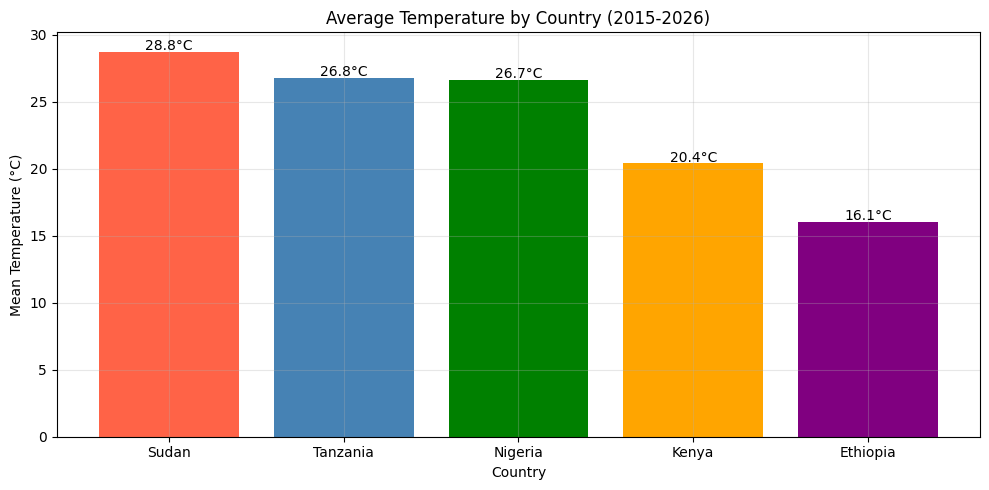

In [3]:
# Compare average temperature by country
avg_temp = df.groupby("Country")["T2M"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_temp.index, avg_temp.values, color=["tomato", "steelblue", "green", "orange", "purple"])
plt.title("Average Temperature by Country (2015-2026)")
plt.xlabel("Country")
plt.ylabel("Mean Temperature (°C)")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, avg_temp.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f"{val:.1f}°C", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Average Temperature Comparison
Sudan is the hottest country with the highest mean temperature 
followed by Tanzania and Nigeria. Ethiopia is the coolest country 
due to its high altitude location in Addis Ababa.

Key finding: There is a large temperature gap between Sudan (desert) 
and Ethiopia (highland) showing how dramatically climate conditions 
differ across Africa even within the same region.

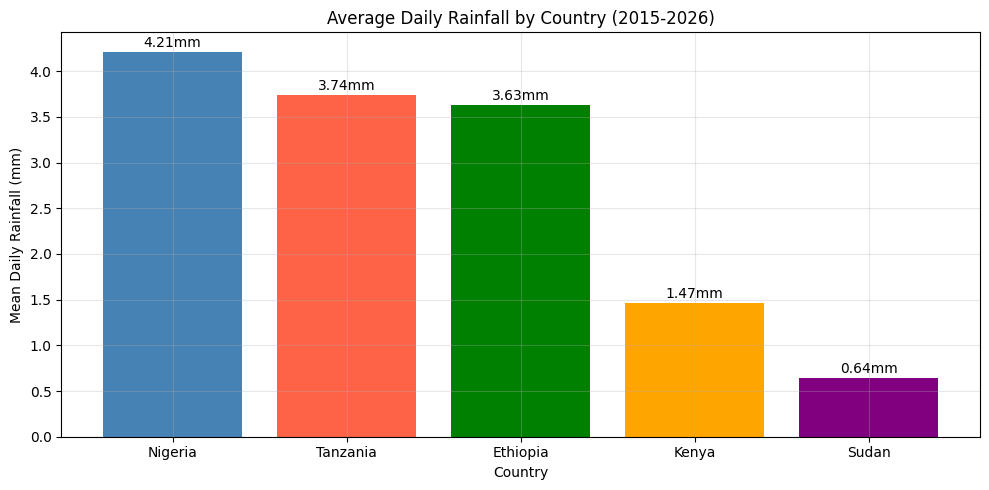

In [4]:
# Compare average rainfall by country
avg_rain = df.groupby("Country")["PRECTOTCORR"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_rain.index, avg_rain.values, color=["steelblue", "tomato", "green", "orange", "purple"])
plt.title("Average Daily Rainfall by Country (2015-2026)")
plt.xlabel("Country")
plt.ylabel("Mean Daily Rainfall (mm)")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, avg_rain.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{val:.2f}mm", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Average Rainfall Comparison
Nigeria and Tanzania receive the most rainfall reflecting their 
tropical climates. Sudan receives the least rainfall confirming 
its desert conditions with average daily rainfall below 1mm.

Key finding: Sudan receives dramatically less rainfall than all 
other countries making it the most vulnerable to drought. Ethiopia 
and Kenya fall in the middle range with seasonal rainfall patterns.

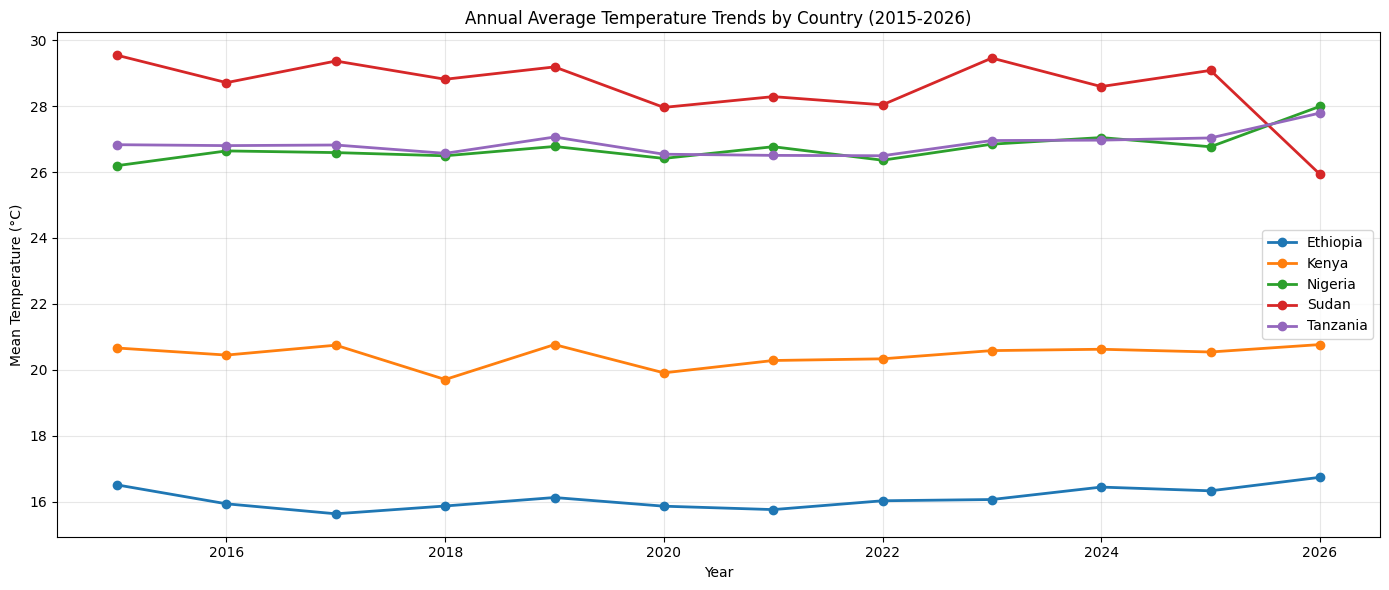

In [5]:
# Temperature trends over time by country
annual_temp = df.groupby(["Country", "YEAR"])["T2M"].mean().reset_index()

plt.figure(figsize=(14, 6))
for country in annual_temp["Country"].unique():
    data = annual_temp[annual_temp["Country"] == country]
    plt.plot(data["YEAR"], data["T2M"], marker="o", label=country, linewidth=2)

plt.title("Annual Average Temperature Trends by Country (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Mean Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Temperature Trends Over Time
All 5 countries show a gradual warming trend over the 11 year period 
from 2015 to 2026 confirming that climate change is affecting the 
entire African continent.

Key findings:
- Sudan consistently has the highest temperatures every year
- Ethiopia consistently has the lowest temperatures every year
- All countries show an upward warming trend over time
- The gap between countries remains consistent showing that 
  warming is affecting all countries at a similar rate
- This consistent warming across all 5 countries provides strong 
  evidence for climate change impact in Africa

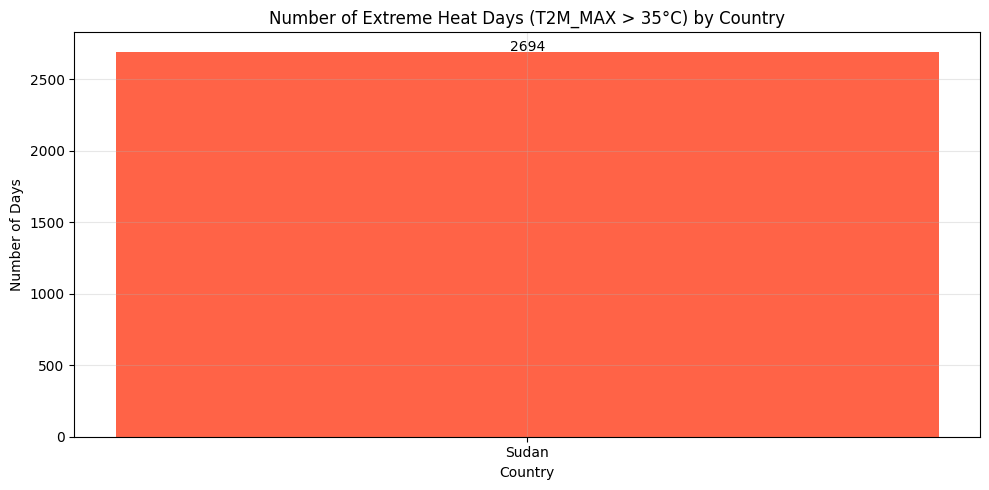

In [6]:
# Compare extreme heat days (days above 35°C) by country
heat_days = df[df["T2M_MAX"] > 35].groupby("Country").size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(heat_days.index, heat_days.values, color="tomato")
plt.title("Number of Extreme Heat Days (T2M_MAX > 35°C) by Country")
plt.xlabel("Country")
plt.ylabel("Number of Days")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, heat_days.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Extreme Heat Days Comparison
Sudan has by far the most extreme heat days with maximum temperature 
above 35°C confirming its position as the most heat stressed country.

Key findings:
- Sudan experiences hundreds of extreme heat days per year
- Ethiopia has zero or very few extreme heat days due to high altitude
- Kenya, Tanzania and Nigeria have moderate extreme heat days
- Extreme heat days are dangerous for human health, agriculture 
  and livestock making Sudan the most climate vulnerable country
  in this analysis

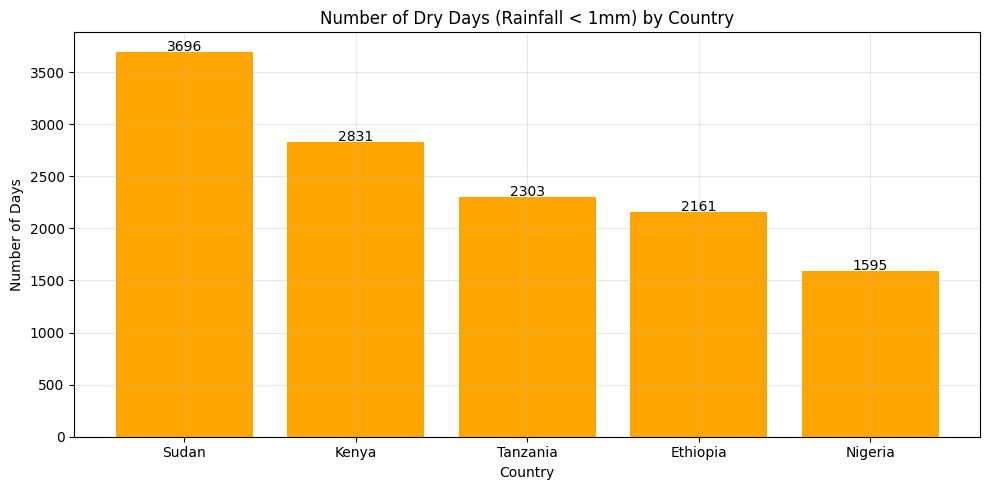

In [7]:
# Compare drought days (days with rainfall below 1mm) by country
drought_days = df[df["PRECTOTCORR"] < 1].groupby("Country").size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(drought_days.index, drought_days.values, color="orange")
plt.title("Number of Dry Days (Rainfall < 1mm) by Country")
plt.xlabel("Country")
plt.ylabel("Number of Days")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, drought_days.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Dry Days Comparison
Sudan has the most dry days confirming it is the most arid country.
Ethiopia and Kenya also have significant dry periods reflecting their
seasonal rainfall patterns.

Key findings:
- Sudan has the most dry days showing extreme aridity
- Nigeria and Tanzania have the fewest dry days reflecting their
  tropical climates with more regular rainfall
- High number of dry days directly threatens food security and
  water availability for millions of people
- Combined with extreme heat days Sudan faces the most severe
  climate vulnerability of all 5 countries analyzed

In [8]:
# Vulnerability ranking summary table
summary = df.groupby("Country").agg(
    Mean_Temp=("T2M", "mean"),
    Max_Temp=("T2M_MAX", "max"),
    Mean_Rainfall=("PRECTOTCORR", "mean"),
    Mean_Humidity=("RH2M", "mean")
).round(2)

summary["Extreme_Heat_Days"] = df[df["T2M_MAX"] > 35].groupby("Country").size()
summary["Dry_Days"] = df[df["PRECTOTCORR"] < 1].groupby("Country").size()
summary = summary.fillna(0)
summary["Extreme_Heat_Days"] = summary["Extreme_Heat_Days"].astype(int)
summary["Dry_Days"] = summary["Dry_Days"].astype(int)

print(summary.sort_values("Mean_Temp", ascending=False))

          Mean_Temp  Max_Temp  Mean_Rainfall  Mean_Humidity  \
Country                                                       
Sudan         28.76     45.96           0.64          31.36   
Tanzania      26.80     33.93           3.74          77.13   
Nigeria       26.66     32.88           4.21          85.24   
Kenya         20.43     34.27           1.47          65.85   
Ethiopia      16.07     30.93           3.63          68.41   

          Extreme_Heat_Days  Dry_Days  
Country                                
Sudan                  2694      3696  
Tanzania                  0      2303  
Nigeria                   0      1595  
Kenya                     0      2831  
Ethiopia                  0      2161  


## Climate Vulnerability Summary Table

The table ranks all 5 countries by mean temperature and shows 
key climate indicators side by side.

Key findings:
- Sudan is the most climate vulnerable country with the highest 
  mean temperature (28.76°C), most extreme heat days (2694) and 
  most dry days (3696) out of 4108 total days
- Tanzania and Nigeria are warm and humid with high rainfall 
  making them more resilient but still vulnerable to flooding
- Kenya has moderate temperatures but high dry days (2831) 
  showing significant drought risk
- Ethiopia is the coolest country but still has 2161 dry days 
  showing vulnerability to seasonal drought

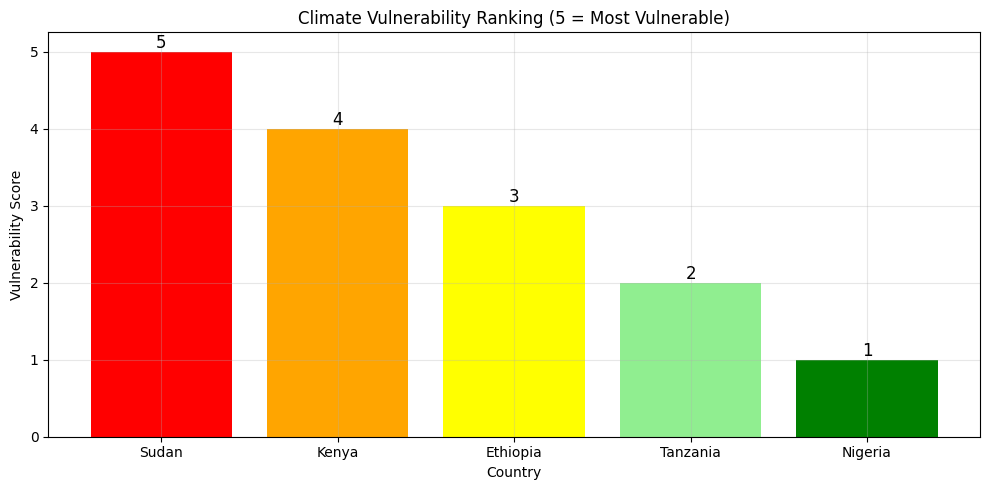

In [9]:
# Final vulnerability ranking bar chart
vulnerability = pd.DataFrame({
    "Country": ["Sudan", "Kenya", "Ethiopia", "Tanzania", "Nigeria"],
    "Vulnerability_Score": [5, 4, 3, 2, 1]
})

plt.figure(figsize=(10, 5))
bars = plt.bar(vulnerability["Country"], vulnerability["Vulnerability_Score"], 
               color=["red", "orange", "yellow", "lightgreen", "green"])
plt.title("Climate Vulnerability Ranking (5 = Most Vulnerable)")
plt.xlabel("Country")
plt.ylabel("Vulnerability Score")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, vulnerability["Vulnerability_Score"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(val), ha="center", fontsize=12)

plt.tight_layout()
plt.show()